# Interpretation of a specific bit

### Limitations of structural keys
We manually define a set of substructures to observe.
* a lot of work
* our own biases in feature selection

### ECFP
Alternative to structural keys: we can observe all substructures
 and hash it into vector.

...ever-popular circular fingerprints (i.e. a "circle" with radius of 2 or 3 bonds around every atom)

= Extended Connectivity Fingerprints (ECFP)
* great amount of information --> hashed to binary vector
* limitation - different features can map onto a single bit :(
* bits: 1024, 2048 (4096)

We will calculate ECFP for our dataset.

In [1]:
import pandas as pd
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import csv
import pandas as pd

In [7]:
from rdkit import RDLogger

# Disable only the warning level
RDLogger.DisableLog('rdApp.warning')

In [2]:
df = pd.read_csv("../my_data/structures_better.csv")
df

,Canonical_SMILES,Mol,Source
0,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(=O)O)NC(=O)[C@...,<rdkit.Chem.rdchem.Mol object at 0x000001B53BC...,DrugBank
1,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,<rdkit.Chem.rdchem.Mol object at 0x000001B53BC...,DrugBank
2,N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H]1...,<rdkit.Chem.rdchem.Mol object at 0x000001B53BC...,DrugBank
3,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,<rdkit.Chem.rdchem.Mol object at 0x000001B53BC...,DrugBank
4,C/C=C/C[C@@H](C)[C@@H](O)[C@H]1C(=O)N[C@@H](CC...,<rdkit.Chem.rdchem.Mol object at 0x000001B53BC...,DrugBank
...,...,...,...
18891,CCc1ncc(C(=O)NCC2CCC(NC(=O)c3ncncc3N)CC2)s1,<rdkit.Chem.rdchem.Mol object at 0x000001B53BE...,ZINC
18892,O=C(N[C@]12CCC[C@@H]1N(C[C@@H]1CCCCO1)CC2)c1cc...,<rdkit.Chem.rdchem.Mol object at 0x000001B53BE...,ZINC
18893,Cc1ocnc1C(=O)Nc1cccc(CNC(=O)[C@H](C)n2ccc(C3CC...,<rdkit.Chem.rdchem.Mol object at 0x000001B53BE...,ZINC
18894,CC(C)(CF)C(=O)N1CC2(CC[C@H](CNC(=O)c3ccnc(Cl)c...,<rdkit.Chem.rdchem.Mol object at 0x000001B53BE...,ZINC


In [3]:
# ECFP are done using RDKit pretty much the same way as MACCS in previous exercise
molecule = Chem.MolFromSmiles("CCO")
fp = Chem.GetMorganFingerprintAsBitVect(molecule, 2, nBits=1024)
# 2 for radius, 1024 for hashed bit vector length
fp

[12:39:50] DEPRECATION WARNING: please use MorganGenerator


In [4]:
fp.ToBitString()

'000000000000000000000000000000000100000000000000000000000000000000000000000000001000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000100000000000000000000000000000000000000000000000000000000000000000000000100000000000000000000000000000000000000000000000000000000000000000000000000000000000000000001000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000100000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000

One vector is really sparse...

In [5]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator

# 1. Properly recreate the Mol objects from the SMILES strings
df['Mol'] = df['Canonical_SMILES'].apply(Chem.MolFromSmiles)

# 2. Drop any rows where SMILES failed to convert (optional but recommended)
df = df.dropna(subset=['Mol'])

# 3A. Create the generator once
# radius=2 is ECFP4
gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# 3B. Apply it to your Mol column
df['ECFP'] = df['Mol'].apply(lambda x: gen.GetFingerprint(x))
df

,Canonical_SMILES,Mol,Source,ECFP
0,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(=O)O)NC(=O)[C@...,<rdkit.Chem.rdchem.Mol object at 0x00000263AF9...,DrugBank,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,<rdkit.Chem.rdchem.Mol object at 0x00000263AF9...,DrugBank,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H]1...,<rdkit.Chem.rdchem.Mol object at 0x00000263AF9...,DrugBank,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,<rdkit.Chem.rdchem.Mol object at 0x00000263AF9...,DrugBank,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,C/C=C/C[C@@H](C)[C@@H](O)[C@H]1C(=O)N[C@@H](CC...,<rdkit.Chem.rdchem.Mol object at 0x00000263AF9...,DrugBank,"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...
18891,CCc1ncc(C(=O)NCC2CCC(NC(=O)c3ncncc3N)CC2)s1,<rdkit.Chem.rdchem.Mol object at 0x00000263AED...,ZINC,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ..."
18892,O=C(N[C@]12CCC[C@@H]1N(C[C@@H]1CCCCO1)CC2)c1cc...,<rdkit.Chem.rdchem.Mol object at 0x00000263AED...,ZINC,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
18893,Cc1ocnc1C(=O)Nc1cccc(CNC(=O)[C@H](C)n2ccc(C3CC...,<rdkit.Chem.rdchem.Mol object at 0x00000263AED...,ZINC,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ..."
18894,CC(C)(CF)C(=O)N1CC2(CC[C@H](CNC(=O)c3ccnc(Cl)c...,<rdkit.Chem.rdchem.Mol object at 0x00000263AED...,ZINC,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [48]:
df["Source"].unique()

<StringArray>
['DrugBank', 'Other', 'ChEMBL', 'DrugBank/ChEMBL', 'ZINC']
Length: 5, dtype: str

Now let's suppose we are interested in a specific bit (e.g., from results of an essay).

## Extraction of a substructure for a specific bit

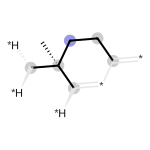

In [13]:
from rdkit.Chem import Draw

def draw_bit(target_bit):
    global fp
    mol_with_bit = None

    for m in df['Mol']:
        fp = AllChem.GetMorganFingerprintAsBitVect(m, radius=2, nBits=2048)
        if fp.GetBit(target_bit):
            mol_with_bit = m
            break

    # 2. Re-run with bitInfo to get the details
    bit_info = {}
    fp = AllChem.GetMorganFingerprintAsBitVect(mol_with_bit, radius=2, nBits=2048, bitInfo=bit_info)

    # 3. Get the atom index and radius for bit 88
    atom_idx, radius = bit_info[target_bit][0]

    # 4. Visualize the fragment
    return Draw.DrawMorganBit(mol_with_bit, target_bit, bit_info)

draw_bit(88)

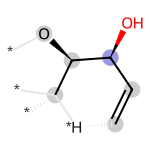

In [14]:
draw_bit(77)

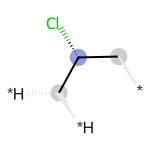

In [15]:
draw_bit(66)

## Fragment analysis
Which bits are the most occured in different source?

In [17]:
from rdkit.Chem import rdFingerprintGenerator

def get_fragment_dict(mol, radius=2, fp_size=2048):
    """
    Returns a dictionary of {bit_id: [(atom_idx, radius), ...]} for a molecule.
    """
    # 1. Initialize Generator and AdditionalOutput
    gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=fp_size)
    ao = rdFingerprintGenerator.AdditionalOutput()
    ao.AllocateBitInfoMap()

    # 2. Generate fingerprint (this populates the AO object)
    gen.GetFingerprint(mol, additionalOutput=ao)

    # 3. Get the BitInfoMap (dict of {bit_id: tuple of tuples})
    bit_info = ao.GetBitInfoMap()

    return bit_info

# Example usage for the first molecule:
example_mol = df['Mol'].iloc[0]
fragments = get_fragment_dict(example_mol)

# Print info for bit 88 if it exists in this molecule
if 88 in fragments:
    print(f"Bit 88 environments: {fragments[88]}")

In [18]:
df['Bit_Info'] = df['Mol'].apply(get_fragment_dict)

In [19]:
from collections import Counter

def get_bit_frequencies(bit_info_series):
    # Flatten all keys (Bit IDs) from the dictionaries into one list
    all_bits = [bit for info in bit_info_series if info for bit in info.keys()]
    return Counter(all_bits)

# Calculate frequencies per source
results = []
for source in df['Source'].unique():
    subset = df[df['Source'] == source]
    counts = get_bit_frequencies(subset['Bit_Info'])

    # Get top 10 for this source
    for bit_id, freq in counts.most_common(10):
        results.append({
            'Source': source,
            'Bit_ID': bit_id,
            'Frequency': freq,
            'Percentage': (freq / len(subset)) * 100
        })

freq_df = pd.DataFrame(results)

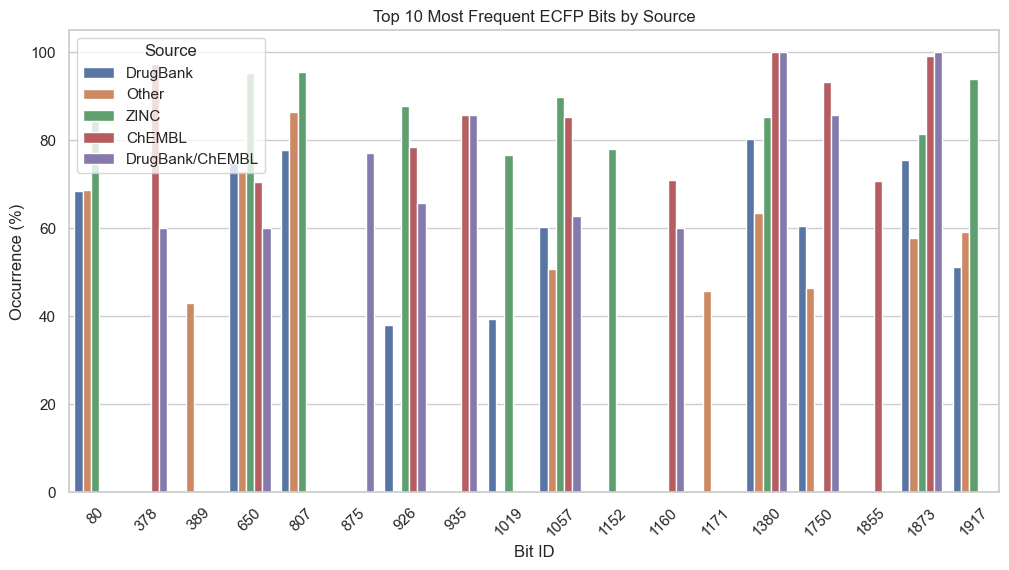

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.barplot(data=freq_df, x='Bit_ID', y='Percentage', hue='Source')
plt.title('Top 10 Most Frequent ECFP Bits by Source')
plt.ylabel('Occurrence (%)')
plt.xlabel('Bit ID')
plt.xticks(rotation=45)
plt.show()

Now let's see what is the bit 1380 from the plot.

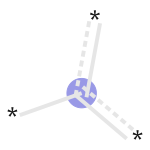

In [30]:
draw_bit(1380)

Hahahah...very nice.
Let's see all the most frequent (top 10) bits that appear in DrugBank.

Displaying Bit ID: 1380


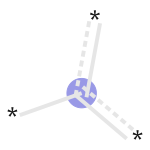

Displaying Bit ID: 807


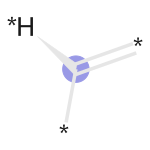

Displaying Bit ID: 1873


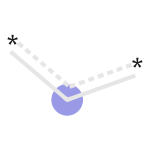

Displaying Bit ID: 650


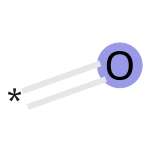

Displaying Bit ID: 80


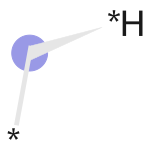

Displaying Bit ID: 1750


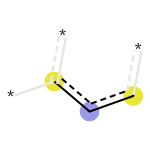

Displaying Bit ID: 1057


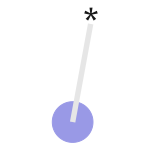

Displaying Bit ID: 1917


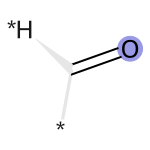

Displaying Bit ID: 1019


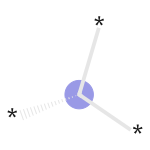

Displaying Bit ID: 926


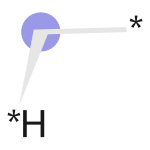

In [32]:
from collections import Counter

# 1. Filter for DrugBank
drugbank_df = df[df['Source'] == 'DrugBank']

# 2. Aggregate all Bit IDs found in the Bit_Info dictionaries
all_db_bits = [bit for info in drugbank_df['Bit_Info'] for bit in info.keys()]

# 3. Identify the 10 most common bits
top_10_bits = [bit for bit, count in Counter(all_db_bits).most_common(10)]

# 4. Apply your drawing function to each of the top 10 bits
for bit in top_10_bits:
    print(f"Displaying Bit ID: {bit}")
    display(draw_bit(bit))

## Tanimoto distance

In [53]:
from rdkit import DataStructs
import numpy as np
import pandas as pd

# 1. Generate the pairwise Tanimoto Similarity Matrix
fps = list(df['ECFP'])
n = len(fps)
matrix = np.zeros((n, n))

for i in range(n):
    # DataStructs.BulkTanimotoSimilarity is much faster than a nested loop
    sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps)
    matrix[i] = [1 - s for s in sims] # Convert similarity to distance

dist_df = pd.DataFrame(matrix)

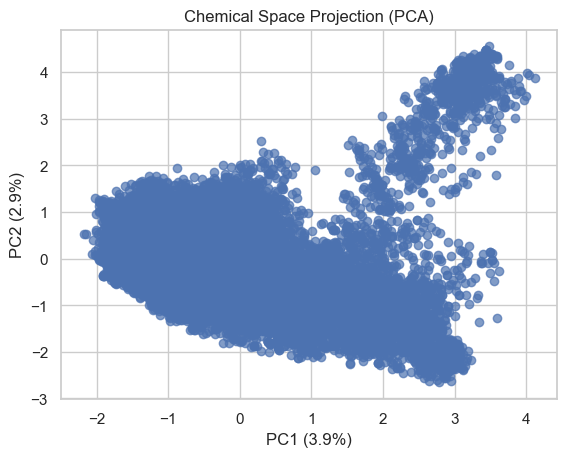

In [54]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Convert fingerprints to a numpy array for sklearn
bit_vectors = np.array([np.array(fp) for fp in fps])

# Reduce to 2 components
pca = PCA(n_components=2)
coords = pca.fit_transform(bit_vectors)

plt.scatter(coords[:, 0], coords[:, 1], alpha=0.7)
plt.title("Chemical Space Projection (PCA)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.show()

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1. Prepare coordinates
X = np.array(df['ECFP'].tolist())

# Reduce to 2 dimensions
tsne = TSNE(n_components=2, random_state=42)
coords = tsne.fit_transform(X)

df['x'] = coords[:, 0]
df['y'] = coords[:, 1]

# 2. Plot with Legend grouped by "Source"
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='x',
    y='y',
    hue='Source',
    style='Source',
    palette='viridis',
    alpha=0.8
)

plt.title("Chemical Space by Source")
plt.legend(title='Source', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()